# 1.0 Import libraries

In [17]:
import numpy as np
import pandas as pd
import altair as alt
import ipywidgets as widgets

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from IPython.display import display

# 2.0 Data load

In [2]:
url = "https://raw.githubusercontent.com/maurope/lmf/main/data/2026_08_20_database_categories_quartiles__visualization_public/compiled_categories_quartiles.csv"
df = pd.read_csv(url)
df

,id_lab,id,subset,no,requisitioner,tax_name,functional_group,n_replicates_nutrition,dm_percentage,ash_dm,...,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,methane_intensity,tddm,ch4_category,tddm_category,lmf_category,lmf_category_rank,quartile,quartile_rank
0,F24-3470,CIAT-11194,1,199.0,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,92.89,9.61,...,15.17,18.02,46.12,59.25,Medium,Not High,Category_2,81.0,Q1,58.0
1,F24-3471,CIAT-11999,1,201.0,Genetic_bank,Stylosanthes guianensis,Herbaceous_legumes,2,93.50,10.46,...,12.98,16.25,46.61,58.55,Medium,Not High,Category_2,88.0,Q1,66.0
2,F24-3472,CIAT-12318,1,203.0,Genetic_bank,Stylosanthes hamata,Herbaceous_legumes,2,94.10,11.08,...,13.99,16.96,52.27,56.88,Medium,Not High,Category_2,148.0,Q2,78.0
3,F24-3427,CIAT-1257,1,113.0,Genetic_bank,Stylosanthes scabra,Herbaceous_legumes,2,92.72,9.52,...,15.71,17.60,46.32,58.95,Medium,Not High,Category_2,84.0,Q1,62.0
4,F24-3473,CIAT-13575,1,205.0,Genetic_bank,Desmodium incanum,Herbaceous_legumes,2,94.14,11.52,...,13.60,16.23,42.43,42.85,Low,Not High,Category_2,46.0,Q3,224.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,F25-2641,NaN,4,63.0,Mauricio Sotelo,Gliricidia sepium,Shrub_Trees,2,93.50,9.41,...,13.69,14.98,45.48,55.91,Medium,Not High,Category_2,151.0,NaN,NaN
689,F25-2641,NaN,4,63.0,Mauricio Sotelo,Gliricidia sepium,Shrub_Trees,2,93.50,9.41,...,13.69,14.98,45.48,55.91,Low,Not High,Category_2,1.0,NaN,NaN
690,F25-2641,NaN,4,63.0,Mauricio Sotelo,Gliricidia sepium,Shrub_Trees,2,93.50,9.41,...,13.69,14.98,45.48,55.91,High,Not High,Category_4,36.0,NaN,NaN
691,F25-2641,NaN,4,63.0,Mauricio Sotelo,Gliricidia sepium,Shrub_Trees,2,93.50,9.41,...,13.69,14.98,45.48,55.91,Low,Not High,Category_2,55.0,NaN,NaN


# 3.0 PCA

In [3]:
df.columns

Index(['id_lab', 'id', 'subset', 'no', 'requisitioner', 'tax_name',
       'functional_group', 'n_replicates_nutrition', 'dm_percentage', 'ash_dm',
       'om_percentage', 'pc_percentage_dm', 'adf_percentage_dm',
       'ndf_percentage_dm', 'n_replicates_gas', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm',
       'ch4_category', 'tddm_category', 'lmf_category', 'lmf_category_rank',
       'quartile', 'quartile_rank'],
      dtype='object')

In [4]:
pca_features = df[['dm_percentage', 'ash_dm','om_percentage', 'pc_percentage_dm',
                   'adf_percentage_dm','ndf_percentage_dm', 'ch4_percentage_in_gas_8h',
                   'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm']]

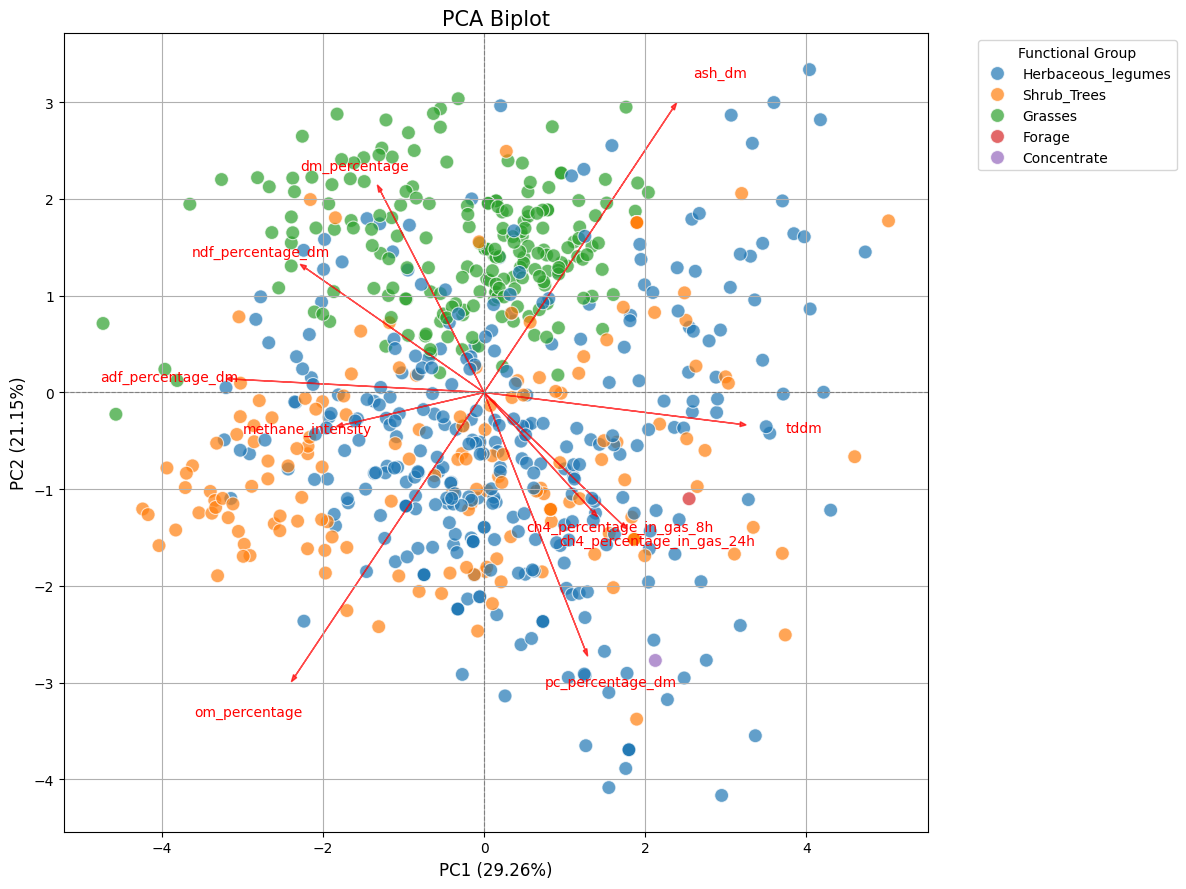

In [5]:
pca_features = df[['dm_percentage', 'ash_dm','om_percentage', 'pc_percentage_dm',
                   'adf_percentage_dm','ndf_percentage_dm', 'ch4_percentage_in_gas_8h',
                   'ch4_percentage_in_gas_24h', 'methane_intensity', 'tddm']]

X = pca_features.copy()

# Replace infinite or very large values with NaN, and then impute or handle
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True) # Impute NaNs with the column mean

# Scale the data before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2) # Reduce to 2 principal components for 2D visualization
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenate with the descriptive columns of df for visualization
final_df = pd.concat([df[['functional_group']], pca_df], axis=1)

# Create the biplot
plt.figure(figsize=(12, 9))
sns.scatterplot(x='PC1', y='PC2', data=final_df, hue='functional_group', s=100, alpha=0.7 )

# Add point labels (optional, can be very dense)
# for i, row in final_df.iterrows():
#     plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['substrate_id'], fontsize=8)

# Add correlation vectors (loadings)
# Get the loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, feature in enumerate(pca_features):
    plt.arrow(0, 0, loadings[i, 0]*4, loadings[i, 1]*4, color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 5, loadings[i, 1] * 4.5, feature, color='r', ha='center', va='center', fontsize=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
plt.title('PCA Biplot', fontsize=15)
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.legend(title='Functional Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# PCA Biplot

## PCA code

In [6]:
def run_pca(
    df,
    pca_vars=None,
    group_column="functional_group",
    n_components=2,
    figsize=(12, 9),
    vector_scale=4,
    point_size=100,
    alpha=0.7
):
    """
    Run PCA and generate a 2D PCA biplot.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    pca_vars : list, optional
        List of columns to use for PCA.
        If None, a default set of variables is used.

    group_column : str
        Column used to define groups in the scatter plot.

    n_components : int
        Number of principal components to calculate.

    figsize : tuple
        Figure size.

    vector_scale : float
        Scaling factor for PCA loading vectors.

    point_size : int
        Size of scatter plot points.

    alpha : float
        Transparency of scatter plot points.

    Returns
    -------
    final_df : pandas.DataFrame
        Original group column plus PCA scores.

    pca : sklearn.decomposition.PCA
        Fitted PCA object.

    scaler : sklearn.preprocessing.StandardScaler
        Fitted scaler.
    """

    # ========================================================
    # Default PCA variables
    # ========================================================

    if pca_vars is None:

        pca_vars = [
            "dm_percentage",
            "ash_dm",
            "om_percentage",
            "pc_percentage_dm",
            "adf_percentage_dm",
            "ndf_percentage_dm",
            "ch4_percentage_in_gas_8h",
            "ch4_percentage_in_gas_24h",
            "methane_intensity",
            "tddm"
        ]


    # ========================================================
    # Check columns
    # ========================================================

    required_columns = pca_vars + [group_column]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"The following columns are missing from the dataframe: "
            f"{missing_columns}"
        )


    # ========================================================
    # Select PCA features
    # ========================================================

    X = df[pca_vars].copy()


    # ========================================================
    # Handle infinite values
    # ========================================================

    X.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )


    # ========================================================
    # Impute missing values
    # ========================================================

    X = X.fillna(X.mean())


    # ========================================================
    # Standardize variables
    # ========================================================

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)


    # ========================================================
    # PCA
    # ========================================================

    pca = PCA(
        n_components=n_components
    )

    principal_components = pca.fit_transform(X_scaled)


    # ========================================================
    # PCA scores dataframe
    # ========================================================

    pc_columns = [
        f"PC{i + 1}"
        for i in range(n_components)
    ]

    pca_df = pd.DataFrame(
        principal_components,
        columns=pc_columns,
        index=df.index
    )


    # ========================================================
    # Combine PCA scores with descriptive information
    # ========================================================

    final_df = pd.concat(
        [
            df[[group_column]],
            pca_df
        ],
        axis=1
    )


    # ========================================================
    # Plot
    # ========================================================

    plt.figure(figsize=figsize)

    sns.scatterplot(
        x="PC1",
        y="PC2",
        data=final_df,
        hue=group_column,
        s=point_size,
        alpha=alpha
    )


    # ========================================================
    # PCA loadings
    # ========================================================

    loadings = (
        pca.components_.T
        * np.sqrt(pca.explained_variance_)
    )


    # ========================================================
    # Add loading vectors
    # ========================================================

    for i, feature in enumerate(pca_vars):

        plt.arrow(
            0,
            0,
            loadings[i, 0] * vector_scale,
            loadings[i, 1] * vector_scale,
            color="red",
            alpha=0.7,
            head_width=0.05
        )

        plt.text(
            loadings[i, 0] * vector_scale * 1.2,
            loadings[i, 1] * vector_scale * 1.2,
            feature,
            color="red",
            ha="center",
            va="center",
            fontsize=10
        )


    # ========================================================
    # Labels and formatting
    # ========================================================

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)",
        fontsize=12
    )

    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)",
        fontsize=12
    )

    plt.title(
        "PCA Biplot",
        fontsize=15
    )

    plt.grid(True)

    plt.axhline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8
    )

    plt.axvline(
        0,
        color="grey",
        linestyle="--",
        linewidth=0.8
    )

    plt.legend(
        title=group_column,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.show()


    # ========================================================
    # Print explained variance
    # ========================================================

    print(
        f"PC1 explains "
        f"{pca.explained_variance_ratio_[0] * 100:.2f}% "
        f"of the variance."
    )

    print(
        f"PC2 explains "
        f"{pca.explained_variance_ratio_[1] * 100:.2f}% "
        f"of the variance."
    )

    print(
        f"PC1 + PC2 explain "
        f"{pca.explained_variance_ratio_[:2].sum() * 100:.2f}% "
        f"of the total variance."
    )


    return final_df, pca, scaler

## PCAs

### All functional groups

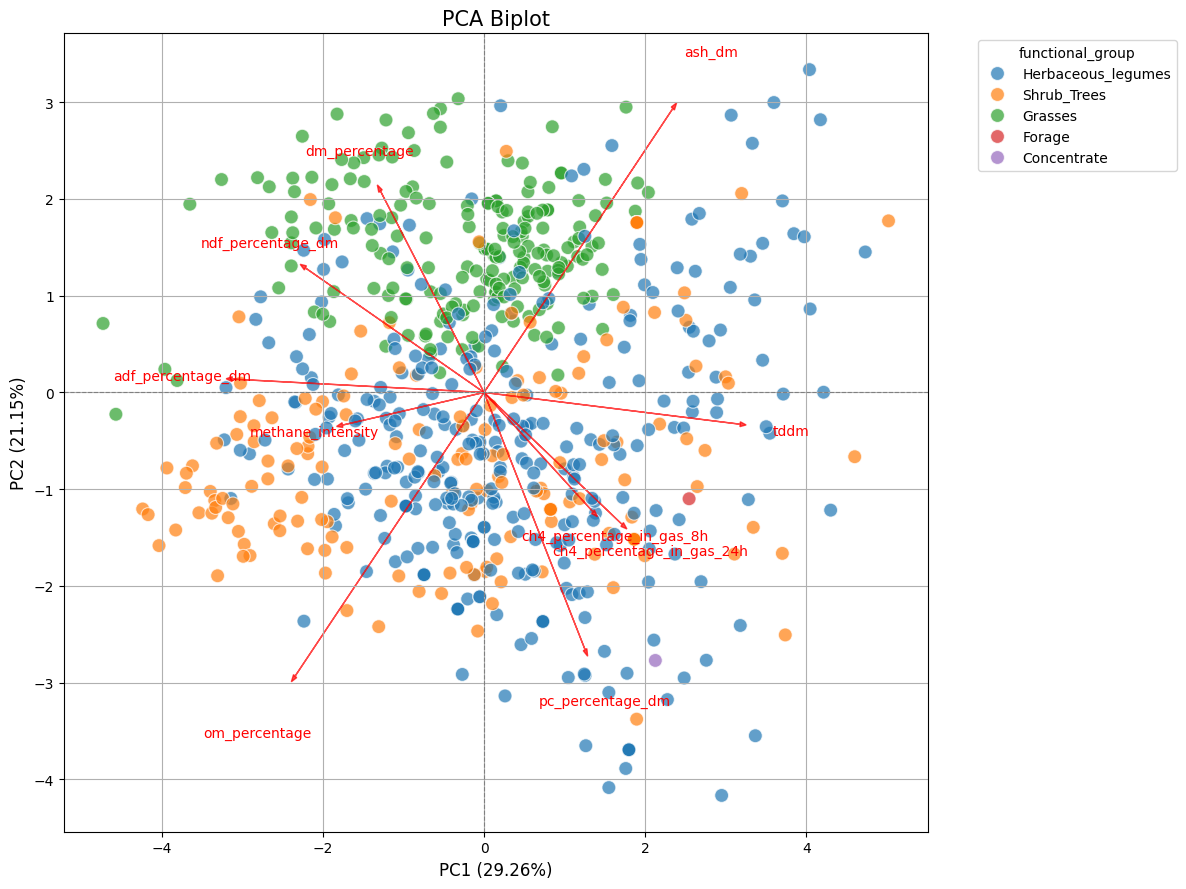

PC1 explains 29.26% of the variance.
PC2 explains 21.15% of the variance.
PC1 + PC2 explain 50.41% of the total variance.


(       functional_group       PC1       PC2
 0    Herbaceous_legumes  0.946506 -1.581842
 1    Herbaceous_legumes  0.139950 -0.514254
 2    Herbaceous_legumes  0.703559 -0.738325
 3    Herbaceous_legumes  0.150198 -1.133914
 4    Herbaceous_legumes -0.485964 -0.331742
 ..                  ...       ...       ...
 688         Shrub_Trees  0.826311 -1.208809
 689         Shrub_Trees  0.826311 -1.208809
 690         Shrub_Trees  0.826311 -1.208809
 691         Shrub_Trees  0.826311 -1.208809
 692         Shrub_Trees  0.826311 -1.208809
 
 [693 rows x 3 columns],
 PCA(n_components=2),
 StandardScaler())

In [7]:
run_pca(
    df=df,
    pca_vars=None,
    group_column="functional_group",
    n_components=2,
    figsize=(12, 9),
    vector_scale=4,
    point_size=100,
    alpha=0.7
)

### Grasses

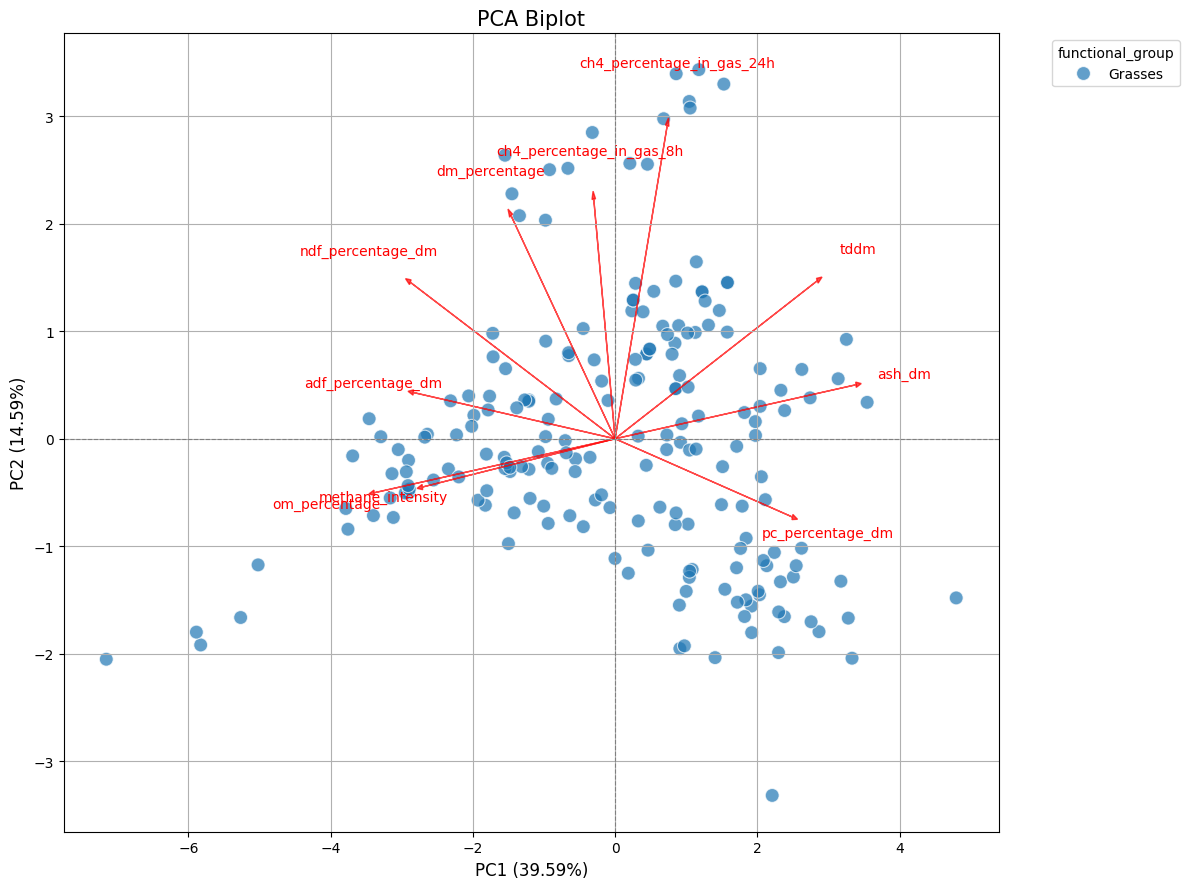

PC1 explains 39.59% of the variance.
PC2 explains 14.59% of the variance.
PC1 + PC2 explain 54.18% of the total variance.


(    functional_group       PC1       PC2
 123          Grasses  0.207817  2.561702
 124          Grasses -0.978749  2.033339
 125          Grasses -1.344294  2.075200
 126          Grasses -0.663089  2.515976
 127          Grasses -0.320166  2.849127
 ..               ...       ...       ...
 683          Grasses -3.689164 -0.159688
 684          Grasses -1.479441 -0.265757
 685          Grasses -5.886608 -1.798805
 686          Grasses -2.910006 -0.435447
 687          Grasses -1.499302 -0.975898
 
 [199 rows x 3 columns],
 PCA(n_components=2),
 StandardScaler())

In [8]:
grasses = df[df["functional_group"] == "Grasses"]

run_pca(
    df=grasses,
    pca_vars=None,
    group_column="functional_group",
    n_components=2,
    figsize=(12, 9),
    vector_scale=4,
    point_size=100,
    alpha=0.7
)

### Herbaceous legumes

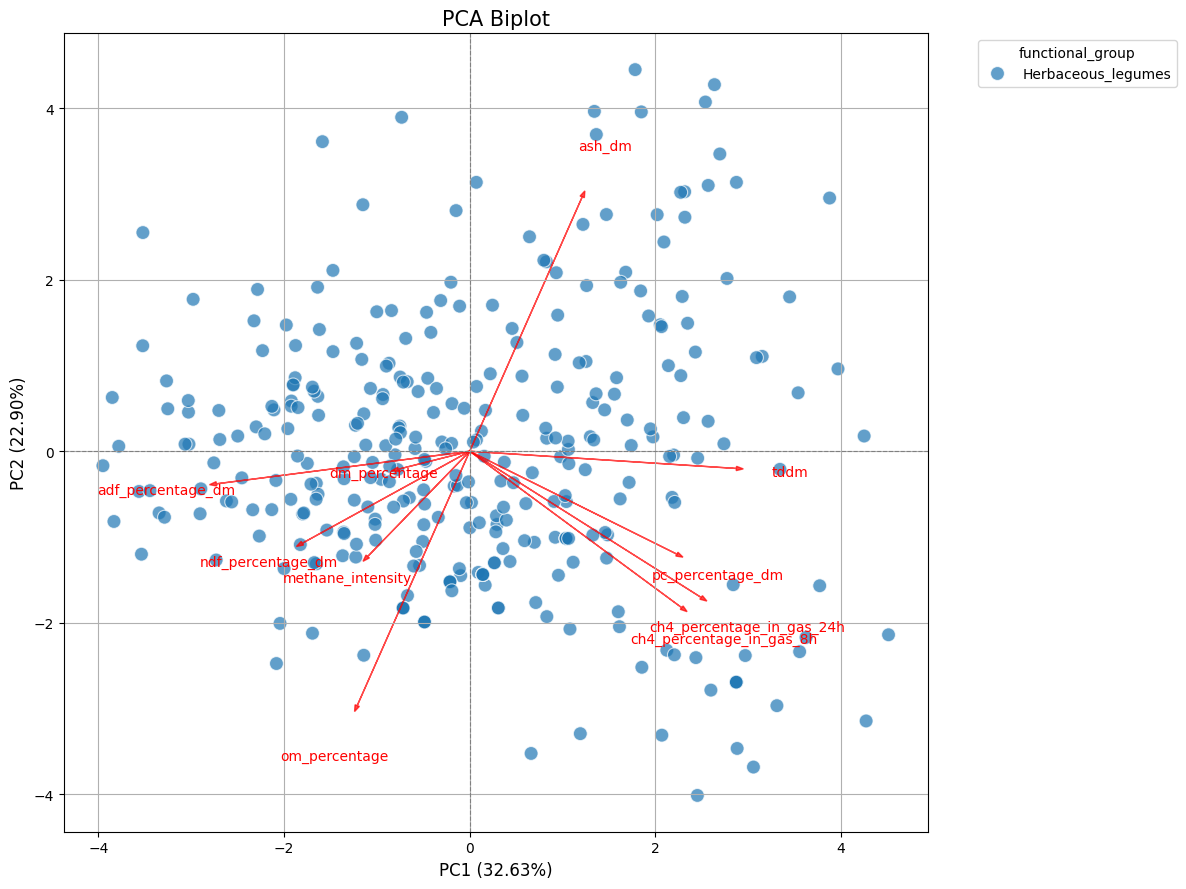

PC1 explains 32.63% of the variance.
PC2 explains 22.90% of the variance.
PC1 + PC2 explain 55.54% of the total variance.


(       functional_group       PC1       PC2
 0    Herbaceous_legumes  1.114195 -1.294001
 1    Herbaceous_legumes -0.167617 -0.405300
 2    Herbaceous_legumes  0.605277 -0.610166
 3    Herbaceous_legumes  0.166490 -1.561559
 4    Herbaceous_legumes -0.776361 -0.213495
 ..                  ...       ...       ...
 671  Herbaceous_legumes -0.035994 -0.600022
 672  Herbaceous_legumes -0.819383 -0.651860
 673  Herbaceous_legumes -1.119313  0.071254
 674  Herbaceous_legumes  0.798937  2.226327
 675  Herbaceous_legumes -0.898515  0.992920
 
 [322 rows x 3 columns],
 PCA(n_components=2),
 StandardScaler())

In [9]:
legumes = df[df["functional_group"] == "Herbaceous_legumes"]

run_pca(
    df=legumes,
    pca_vars=None,
    group_column="functional_group",
    n_components=2,
    figsize=(12, 9),
    vector_scale=3.5,
    point_size=100,
    alpha=0.7
)

### Shrubs and Trees

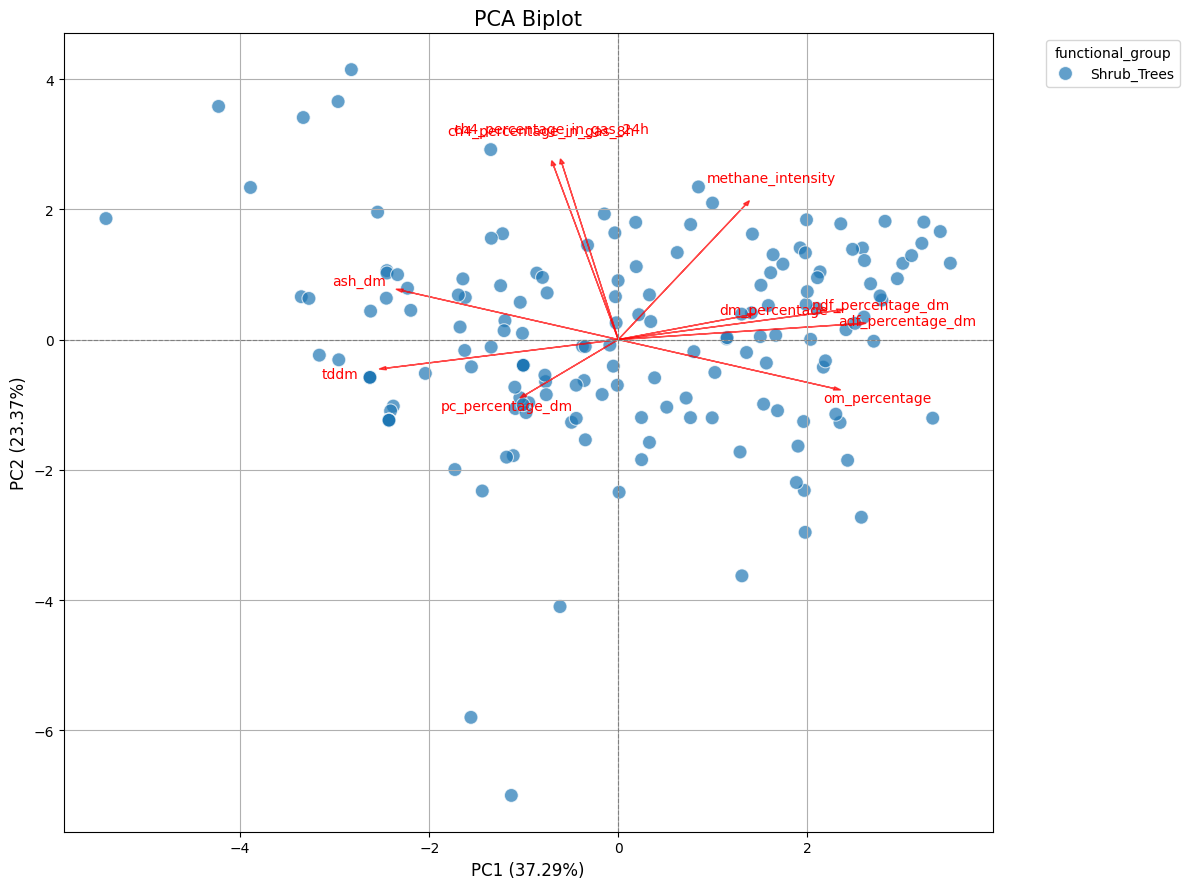

PC1 explains 37.29% of the variance.
PC2 explains 23.37% of the variance.
PC1 + PC2 explain 60.66% of the total variance.


(    functional_group       PC1       PC2
 7        Shrub_Trees  0.216924  0.381583
 8        Shrub_Trees -1.244859  0.827044
 12       Shrub_Trees -0.088801 -0.085228
 14       Shrub_Trees -0.752879  0.715764
 22       Shrub_Trees -1.013732  0.095118
 ..               ...       ...       ...
 688      Shrub_Trees -1.005258 -0.394986
 689      Shrub_Trees -1.005258 -0.394986
 690      Shrub_Trees -1.005258 -0.394986
 691      Shrub_Trees -1.005258 -0.394986
 692      Shrub_Trees -1.005258 -0.394986
 
 [165 rows x 3 columns],
 PCA(n_components=2),
 StandardScaler())

In [10]:
shrubs = df[df["functional_group"] == "Shrub_Trees"]

run_pca(
    df=shrubs,
    pca_vars=None,
    group_column="functional_group",
    n_components=2,
    figsize=(12, 9),
    vector_scale=3,
    point_size=100,
    alpha=0.7
)

# PCA Interactivo

In [16]:
# ============================================================
# PCA variables
# ============================================================

pca_vars = [
    "dm_percentage",
    "ash_dm",
    "om_percentage",
    "pc_percentage_dm",
    "adf_percentage_dm",
    "ndf_percentage_dm",
    "ch4_percentage_in_gas_8h",
    "ch4_percentage_in_gas_24h",
    "methane_intensity",
    "tddm"
]


# ============================================================
# Column labels
# ============================================================

column_labels = {
    "id": "Accession identifier",
    "id_lab": "Laboratory sample identifier",
    "tax_name": "Taxonomic name",
    "functional_group": "Functional group",
    "subset": "Experimental subset",
    "n_replicates_nutrition": "No. replicates (Nutrition)",
    "dm_percentage": "Dry matter (%)",
    "ash_dm": "Ash (% DM)",
    "om_percentage": "Organic matter (% DM)",
    "pc_percentage_dm": "Crude protein (% DM)",
    "adf_percentage_dm": "ADF (% DM)",
    "ndf_percentage_dm": "NDF (% DM)",
    "n_replicates_gas": "No. replicates (Gas)",
    "ch4_percentage_in_gas_8h": "Methane in Gas (8 h, %)",
    "ch4_percentage_in_gas_24h": "Methane in Gas (24 h, %)",
    "methane_intensity": "Methane intensity",
    "tddm": "TDDM (%)",
    "ch4_category": "Methane category",
    "tddm_category": "TDDM category",
    "lmf_category": "LMF category",
    "lmf_category_rank": "Position on LMF category",
    "quartile": "LMF quartile",
    "quartile_rank": "LMF ranking"
}


# ============================================================
# Tooltip columns
# ============================================================

tooltip_columns = [
    "id",
    "id_lab",
    "tax_name",
    "functional_group",
    "subset",
    "n_replicates_nutrition",
    "dm_percentage",
    "ash_dm",
    "om_percentage",
    "pc_percentage_dm",
    "adf_percentage_dm",
    "ndf_percentage_dm",
    "n_replicates_gas",
    "ch4_percentage_in_gas_8h",
    "ch4_percentage_in_gas_24h",
    "methane_intensity",
    "tddm",
    "ch4_category",
    "tddm_category",
    "lmf_category",
    "lmf_category_rank",
    "quartile",
    "quartile_rank"
]


# ============================================================
# Check PCA variables
# ============================================================

missing_pca_vars = [
    column
    for column in pca_vars
    if column not in df.columns
]

if missing_pca_vars:

    raise ValueError(
        "The following PCA variables are missing from df: "
        f"{missing_pca_vars}"
    )


# ============================================================
# Functional groups
# ============================================================

functional_groups = sorted(
    df["functional_group"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)


# ============================================================
# Widget
# ============================================================

pca_functional_widget = widgets.Dropdown(
    options=["All"] + functional_groups,
    value="All",
    description="Group:"
)


# ============================================================
# PCA function
# ============================================================

def plot_pca(functional_group):

    # --------------------------------------------------------
    # Filter data by functional group
    # --------------------------------------------------------

    if functional_group == "All":

        data = df.copy()

    else:

        data = df[
            df["functional_group"]
            .astype(str)
            .str.strip()
            == functional_group
        ].copy()


    # --------------------------------------------------------
    # Check number of observations
    # --------------------------------------------------------

    if len(data) < 3:

        print(
            f"Not enough observations for '{functional_group}'. "
            f"Found {len(data)} samples."
        )

        return


    # --------------------------------------------------------
    # PCA matrix
    # --------------------------------------------------------

    X = data[pca_vars].copy()


    # --------------------------------------------------------
    # Replace infinite values with NaN
    # --------------------------------------------------------

    X.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )


    # --------------------------------------------------------
    # Impute missing values with column means
    # --------------------------------------------------------

    X = X.fillna(
        X.mean()
    )


    # --------------------------------------------------------
    # Check remaining NaNs
    # --------------------------------------------------------

    if X.isna().any().any():

        bad_columns = X.columns[
            X.isna().any()
        ].tolist()

        print(
            "These variables still contain missing values: "
            f"{bad_columns}"
        )

        return


    # --------------------------------------------------------
    # Check zero variance
    # --------------------------------------------------------

    zero_variance = [
        column
        for column in pca_vars
        if X[column].nunique() <= 1
    ]

    if zero_variance:

        print(
            "These variables have zero variance for "
            f"'{functional_group}': {zero_variance}"
        )

        return


    # ========================================================
    # Standardization
    # ========================================================

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)


    # ========================================================
    # PCA
    # ========================================================

    pca = PCA(
        n_components=2
    )

    principal_components = pca.fit_transform(
        X_scaled
    )


    # ========================================================
    # PCA scores
    # ========================================================

    pca_df = pd.DataFrame(
        principal_components,
        columns=["PC1", "PC2"],
        index=data.index
    )


    # ========================================================
    # Keep all columns needed for the tooltip
    # ========================================================

    available_tooltip_columns = [
        column
        for column in tooltip_columns
        if column in data.columns
    ]

    final_df = pd.concat(
        [
            data[available_tooltip_columns],
            pca_df
        ],
        axis=1
    )


    # ========================================================
    # PCA loadings
    # ========================================================

    loadings = (
        pca.components_.T
        * np.sqrt(
            pca.explained_variance_
        )
    )


    loading_df = pd.DataFrame(
        loadings,
        columns=["PC1", "PC2"],
        index=pca_vars
    ).reset_index()


    loading_df.rename(
        columns={
            "index": "variable"
        },
        inplace=True
    )


    # ========================================================
    # Descriptive names for loading variables
    # ========================================================

    loading_df["variable_label"] = (
        loading_df["variable"]
        .map(
            lambda x: column_labels.get(
                x,
                x.replace("_", " ").title()
            )
        )
    )


    # ========================================================
    # Scale loading vectors
    # ========================================================

    max_pc = np.max(
        np.abs(
            final_df[
                ["PC1", "PC2"]
            ].values
        )
    )

    max_loading = np.max(
        np.abs(
            loading_df[
                ["PC1", "PC2"]
            ].values
        )
    )


    if max_loading == 0:

        vector_scale = 1

    else:

        vector_scale = (
            max_pc
            / max_loading
            * 0.7
        )


    loading_df["PC1_scaled"] = (
        loading_df["PC1"]
        * vector_scale
    )

    loading_df["PC2_scaled"] = (
        loading_df["PC2"]
        * vector_scale
    )


    # ========================================================
    # Vector dataframe
    # ========================================================

    vector_rows = []

    for _, row in loading_df.iterrows():

        vector_rows.append(
            {
                "x": 0,
                "y": 0,
                "x2": row["PC1_scaled"],
                "y2": row["PC2_scaled"],
                "variable": row["variable_label"]
            }
        )

    vector_df = pd.DataFrame(
        vector_rows
    )


    # ========================================================
    # Tooltip
    # ========================================================

    tooltip = [
        alt.Tooltip(
            column,
            title=column_labels.get(
                column,
                column.replace("_", " ").title()
            )
        )
        for column in tooltip_columns
        if column in final_df.columns
    ]

    # Add PCA coordinates
    tooltip += [
        alt.Tooltip(
            "PC1:Q",
            title="PC1",
            format=".3f"
        ),

        alt.Tooltip(
            "PC2:Q",
            title="PC2",
            format=".3f"
        )
    ]


    # ========================================================
    # PCA points
    # ========================================================

    points = (
        alt.Chart(final_df)
        .mark_circle(
            size=70
        )
        .encode(

            x=alt.X(
                "PC1:Q",
                title=(
                    f"PC1 "
                    f"({pca.explained_variance_ratio_[0] * 100:.2f}%)"
                )
            ),

            y=alt.Y(
                "PC2:Q",
                title=(
                    f"PC2 "
                    f"({pca.explained_variance_ratio_[1] * 100:.2f}%)"
                )
            ),

            color=alt.Color(
                "functional_group:N",
                legend=alt.Legend(
                    title="Functional Group"
                )
            ),

            tooltip=tooltip
        )
    )


    # ========================================================
    # Loading vectors
    # ========================================================

    vectors = (
        alt.Chart(
            vector_df
        )
        .mark_rule(
            color="red",
            opacity=0.7
        )
        .encode(

            x=alt.X(
                "x:Q"
            ),

            y=alt.Y(
                "y:Q"
            ),

            x2="x2:Q",

            y2="y2:Q"
        )
    )


    # ========================================================
    # Loading labels
    # ========================================================

    labels = (
        alt.Chart(
            vector_df
        )
        .mark_text(
            align="left",
            dx=5,
            dy=-5,
            color="darkred",
            fontWeight="bold",
            fontSize=12
        )
        .encode(

            x=alt.X(
                "x2:Q"
            ),

            y=alt.Y(
                "y2:Q"
            ),

            text=alt.Text(
                "variable:N"
            )
        )
    )


    # ========================================================
    # Final PCA biplot
    # ========================================================

    final_plot = (
        points
        + vectors
        + labels
    ).properties(

        width=850,

        height=600,

        title=(
            f"PCA Biplot — "
            f"{functional_group} "
            f"(n = {len(final_df)})"
        )

    ).configure_axis(

        labelFontSize=14,

        titleFontSize=18

    ).configure_legend(

        titleFontSize=16,

        labelFontSize=14

    ).configure_title(

        fontSize=20

    ).interactive()


    # ========================================================
    # Display
    # ========================================================

    display(
        final_plot
    )


# ============================================================
# Interactive output
# ============================================================

pca_output = widgets.interactive_output(
    plot_pca,
    {
        "functional_group":
            pca_functional_widget
    }
)




In [15]:
# ============================================================
# Display widget
# ============================================================

display(
    widgets.VBox([
        pca_functional_widget,
        pca_output
    ])
)

alt.LayerChart(...)